In [1]:
import os
import pickle
import scanpy as sc
import numpy as np
import pyranges as pr
import pandas as pd
import os
import pycisTopic
%matplotlib inline
from gtfparse import read_gtf

main_dir = '/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/glut-ra_glut-arco-1_run2_seurat-snrna-clustering/'
data_dir = os.path.join(main_dir, 'anndata_rna/')
work_dir = os.path.join(main_dir, 'pycisTopic/')
tmp_dir = '/tmp/motor-pathway_multiome'
adata_fname = os.path.join(data_dir, 'adata.h5ad')

# Load scRNA anndata

In [2]:
adata = sc.read_h5ad(adata_fname)

In [3]:
adata.obs.sample_short.value_counts()

pd.crosstab(adata.obs['sample_short'], adata.obs['cluster'])

cluster,Glut-Arco-1,Glut-RA
sample_short,,
arco_run2,442,8
nc_run1,2,0
ra_run2,43,250


In [4]:
cluster_var = 'cluster'
cell_data = adata.obs
cell_data[cluster_var] = cell_data[cluster_var].astype(str) # set data type of the celltype column to str, otherwise the export_pseudobulk function will complain.
#cell_data[cluster_var] = cell_data[cluster_var].astype(str)
cell_data[cluster_var]


ACTCAGTAGGCCTTAG-1___nc_run1      Glut-Arco-1
GAGTTTGGTTATGTGG-1___nc_run1      Glut-Arco-1
AAAGCCCGTTCCGGGA-1___ra_run2          Glut-RA
AAAGGACGTGTGTGGT-1___ra_run2          Glut-RA
AAAGGAGCACTAGCGT-1___ra_run2          Glut-RA
                                     ...     
TTTGACCGTTGGTTGA-1___arco_run2    Glut-Arco-1
TTTGCATTCCCGAACA-1___arco_run2    Glut-Arco-1
TTTGGTGCATGTCGCG-1___arco_run2    Glut-Arco-1
TTTGTGAAGACTTACA-1___arco_run2    Glut-Arco-1
TTTGTGGCACAGAACG-1___arco_run2    Glut-Arco-1
Name: cluster, Length: 745, dtype: object

## scATAC-seq

In [5]:
in_dir = '/home/brad/nest/multiome'
#make a directory for to store the processed scRNA-seq data.
if not os.path.exists(os.path.join(work_dir, 'scATAC')):
    os.makedirs(os.path.join(work_dir, 'scATAC'))

In [6]:
cell_data.sample_short.drop_duplicates()

ACTCAGTAGGCCTTAG-1___nc_run1        nc_run1
AAAGCCCGTTCCGGGA-1___ra_run2        ra_run2
AAACAGCCAATTTGGT-1___arco_run2    arco_run2
Name: sample_short, dtype: category
Categories (3, object): ['arco_run2', 'nc_run1', 'ra_run2']

In [7]:
fragments_dict = {'ra_run2': os.path.join(in_dir, '220105_motor-pathway_run2/ra_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz'),
                 'arco_run2': os.path.join(in_dir, '220105_motor-pathway_run2/arco_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz'),
                 #'ra_run3': os.path.join(in_dir, '220708_ra-arco_multiome_run3/ra_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz'),
                 #'arco_run3': os.path.join(in_dir, '220708_ra-arco_multiome_run3/arco_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz'),
                 #'hvc_run1': os.path.join(in_dir, '210830_hvc-nc_run1/hvc_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz'),
                 'nc_run1': os.path.join(in_dir,  '210830_hvc-nc_run1/nc_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz'),
                 #'hvc_run2': os.path.join(in_dir, '220105_motor-pathway_run2/hvc_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz'),
                 #'nc_run2': os.path.join(in_dir, '220105_motor-pathway_run2/nc_lonStrDom2_3p_merge_ucsc/outs/atac_fragments.tsv.gz')
                 }  

In [8]:
# Get chromosome sizes (for lonStrDom2 here)

#chromsize_fname = '/home/brad/nest/assembly/lonStrDom2/ncbi/sequence_report.txt'
chromsize_fname = '/home/brad/nest/assembly/lonStrDom2/ucsc/chrom.sizes.ucsc'
chromsizes=pd.read_table(chromsize_fname, skiprows=0, delimiter="\\t", header=None)
chromsizes.columns.tolist()
chromsizes.rename({0:"Chromosome", 1:'End'}, axis='columns', inplace=True, errors="raise")
chromsizes['Start']=[0]*chromsizes.shape[0]
chromsizes=chromsizes.loc[:,['Chromosome', 'Start', 'End']]
chromsizes=pr.PyRanges(chromsizes)
chromsizes

/tmp/ipykernel_1062161/2114098398.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  chromsizes=pd.read_table(chromsize_fname, skiprows=0, delimiter="\\t", header=None)


,Chromosome,Start,End
0,chr1,0,114882317
1,chr1A,0,72268309
2,chr2,0,152210352
3,chr3,0,113230790
4,chr4,0,71975342
...,...,...,...
2010,chrUn_NW_021820216v1,0,1622
2011,chrUn_NW_021820217v1,0,1583
2012,chrUn_NW_021820218v1,0,12887
2013,chrUn_NW_021820219v1,0,36677


In [9]:
import ray
ray.shutdown()

In [10]:
cell_data.sample_short.drop_duplicates()

ACTCAGTAGGCCTTAG-1___nc_run1        nc_run1
AAAGCCCGTTCCGGGA-1___ra_run2        ra_run2
AAACAGCCAATTTGGT-1___arco_run2    arco_run2
Name: sample_short, dtype: category
Categories (3, object): ['arco_run2', 'nc_run1', 'ra_run2']

In [11]:
### Fix cell_data cell name to match cisTopic object
"""
cell_data_mod = cell_data.copy()
cell_data_mod.index = cell_data_mod.index.str.replace("-[0-9]", "-1", regex=True)
indices = cell_data_mod.index.to_list()
cell_data_mod["barcode"] = cell_data_mod.index
out = cell_data_mod.apply(lambda x: '___'.join([x.barcode, f"{x.sample_short}"]), axis=1)
cell_data_mod.index = out
cell_data_mod
"""

'\ncell_data_mod = cell_data.copy()\ncell_data_mod.index = cell_data_mod.index.str.replace("-[0-9]", "-1", regex=True)\nindices = cell_data_mod.index.to_list()\ncell_data_mod["barcode"] = cell_data_mod.index\nout = cell_data_mod.apply(lambda x: \'___\'.join([x.barcode, f"{x.sample_short}"]), axis=1)\ncell_data_mod.index = out\ncell_data_mod\n'

In [12]:
redo = False
if redo: 
    from pycisTopic.pseudobulk_peak_calling import export_pseudobulk
    
    bw_paths, bed_paths = export_pseudobulk(
        input_data = cell_data,
        variable = cluster_var,
        sample_id_col = "sample_short",
        chromsizes = chromsizes,
        bed_path = os.path.join(work_dir, 'scATAC/consensus_peak_calling/pseudobulk_bed_files/'),  # specify where pseudobulk_bed_files should be stored
        bigwig_path = os.path.join(work_dir, 'scATAC/consensus_peak_calling/pseudobulk_bw_files/'),
        path_to_fragments = fragments_dict,
        n_cpu = 20,
        normalize_bigwig = True,
        temp_dir = tmp_dir,
        split_pattern = "___"
    )

In [13]:
redo = False
if redo: 
    pickle.dump(bed_paths, 
                open(os.path.join(work_dir, 'scATAC/consensus_peak_calling/pseudobulk_bed_files/bed_paths.pkl'), 'wb'))
    pickle.dump(bw_paths,
               open(os.path.join(work_dir, 'scATAC/consensus_peak_calling/pseudobulk_bed_files/bw_paths.pkl'), 'wb'))
else:
    bed_paths = pickle.load(open(os.path.join(work_dir, 'scATAC/consensus_peak_calling/pseudobulk_bed_files/bed_paths.pkl'), 'rb'))
    bw_paths =  pickle.load(open(os.path.join(work_dir, 'scATAC/consensus_peak_calling/pseudobulk_bed_files/bw_paths.pkl'), 'rb'))
    print(bed_paths)
    

{'Glut-Arco-1': '/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/glut-ra_glut-arco-1_run2_seurat-snrna-clustering/pycisTopic/scATAC/consensus_peak_calling/pseudobulk_bed_files/Glut-Arco-1.fragments.tsv.gz', 'Glut-RA': '/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/glut-ra_glut-arco-1_run2_seurat-snrna-clustering/pycisTopic/scATAC/consensus_peak_calling/pseudobulk_bed_files/Glut-RA.fragments.tsv.gz'}


## Call peaks per pseudobulk profile

In [14]:
redo = False

if redo:
    from pycisTopic.pseudobulk_peak_calling import peak_calling
    macs_path='/home/brad/micromamba/envs/scenicplus/bin/macs2'

    # Run peak calling
    narrow_peaks_dict = peak_calling(macs_path,
                                     bed_paths,
                                     os.path.join(work_dir, 'scATAC/consensus_peak_calling/MACS/'),
                                     genome_size=1.1e9,
                                     n_cpu=40,
                                     input_format='BEDPE',
                                     shift=73, 
                                     ext_size=146,
                                     keep_dup = 'all',
                                     q_value = 0.05,
                                     _temp_dir = os.path.join(tmp_dir, 'ray_spill'))
    

In [15]:
redo = False

if redo:
    pickle.dump(narrow_peaks_dict, 
                open(os.path.join(work_dir, 'scATAC/consensus_peak_calling/MACS/narrow_peaks_dict.pkl'), 'wb'))
else:
    narrow_peaks_dict = pickle.load(open(os.path.join(work_dir, 'scATAC/consensus_peak_calling/MACS/narrow_peaks_dict.pkl'), 'rb'))

Merge peaks into consensus peak set, for more info see [pyCistopic read the docs](https://pycistopic.readthedocs.io/en/latest/).

In [16]:
bed_fname = os.path.join(work_dir, 'scATAC/consensus_peak_calling/consensus_regions.bed')
redo = False
if redo:

    from pycisTopic.iterative_peak_calling import *
    # Other param
    peak_half_width = 250
    #path_to_blacklist= '../../pycisTopic/blacklist/hg38-blacklist.v2.bed'
    # Get consensus peaks
    #consensus_peaks=get_consensus_peaks(narrow_peaks_dict, peak_half_width, chromsizes=chromsizes, path_to_blacklist=path_to_blacklist)
    consensus_peaks=get_consensus_peaks(narrow_peaks_dict, peak_half_width, chromsizes=chromsizes)

    consensus_peaks.to_bed(
        path = bed_fname, 
        keep=True, 
        compression='infer', 
        chain=False)
else:
    consensus_peaks = pr.read_bed(bed_fname)

#### Quality control

Next we will calculate sample level and cell-barcode level quality control statistics.

Barcode level QC stats include (these stats will be used to filter good quality cell barcodes from bad quality ones):

1. Log number of unique fragments per cell barcode.
2. FRIP per cell barcode.
3. TSS enrichment per cell barcode.
4. Duplication rate per cell barcode.

In [17]:
from pandas import read_table
gtf_fname = "/home/brad/nest/assembly/lonStrDom2/ncbi/merge_gtf_with_3p/GCF_005870125.1_lonStrDom2_genomic_stringtie_FPKMthresh0.5_FPKMmaxfrac0.1_minhits5_slim_ucsc.gtf"
gtf = read_table(gtf_fname, skiprows=3, header=0, names=['Chromosome', 'Source', 'Element', 'Start', 'End', 'Score', 'Strand', 'Number', 'Fields'])

qc_dir = os.path.join(work_dir, 'qc')
os.makedirs(qc_dir, exist_ok=True)
annot = gtf[gtf.Element=="gene"]
annot[["Gene_id", "ID", "Name", "Gene", "None"]] = annot.Fields.str.split('; ',expand=True)
annot['Gene'] = annot['Gene'].str.replace("gene ", "") 
annot['Gene'] = annot['Gene'].str.replace(";", "") 
annot['Gene'] = annot['Gene'].str.replace("\"", "") 
annot['Gene_id'] = annot['Gene_id'].str.replace("gene_id ", "") 
annot['Gene_id'] = annot['Gene_id'].str.replace("\"", "") 
res = ~annot['Gene_id'].str.contains("pseudo|^LOC[0-9]+", regex=True)
annot = annot[res]
annot['End'] = annot['Start'] + 1
annot['Score'] = '.'
annot = annot[['Chromosome', 'Start', 'End', 'Gene', 'Score', 'Strand']]
annot = annot.rename(columns={'Chromosome':'# Chromosome'})

annot['Transcript_type'] = "protein_coding"
annot.head(10)

tss_fname = os.path.join(qc_dir, 'tss.bed')
annot.to_csv(tss_fname, sep='\t')
annot

/tmp/ipykernel_1062161/488824909.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annot[["Gene_id", "ID", "Name", "Gene", "None"]] = annot.Fields.str.split('; ',expand=True)
/tmp/ipykernel_1062161/488824909.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annot[["Gene_id", "ID", "Name", "Gene", "None"]] = annot.Fields.str.split('; ',expand=True)
/tmp/ipykernel_1062161/488824909.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

,# Chromosome,Start,End,Gene,Score,Strand,Transcript_type
19,chrUn_NW_021819257v1,21855,21856,TAF6,.,-,protein_coding
65,chrUn_NW_021819126v1,46745,46746,POLR2I,.,-,protein_coding
81,chrUn_NW_021819126v1,60039,60040,TBCB,.,+,protein_coding
107,chrUn_NW_021819126v1,93601,93602,ARHGAP35,.,-,protein_coding
122,chrUn_NW_021819126v1,131152,131153,AP2S1,.,+,protein_coding
...,...,...,...,...,...,...,...
911357,chrUn_NW_021819121v1,157963,157964,CARM1,.,+,protein_coding
911462,chrUn_NW_021820131v1,8,9,MAG,.,+,protein_coding
911569,chrUn_NW_021819174v1,12793,12794,B9D2,.,-,protein_coding
911612,chrUn_NW_021819116v1,21620,21621,MAP2K7,.,-,protein_coding


In [18]:
regions_bed_filename = bed_fname
tss_bed_filename = tss_fname

pycistopic_qc_commands_filename = "pycistopic_qc_commands.txt"

# Create text file with all pycistopic qc command lines.
with open(pycistopic_qc_commands_filename, "w") as fh:
    for sample, fragment_filename in fragments_dict.items():
        print(
            "/home/brad/micromamba/envs/scenicplus/bin/pycistopic qc",
            f"--fragments {fragment_filename}",
            f"--regions {regions_bed_filename}",
            f"--tss {tss_bed_filename}",
            f"--output {qc_dir}/{sample}",
            sep=" ",
            file=fh,
        )


In [19]:
# Run in terminal 
# micromamba activate scenicplus
redo = False
if redo:
    !cat pycistopic_qc_commands.txt | parallel -j 40 {}

Academic tradition requires you to cite works you base your article on.
If you use programs that use GNU Parallel to process data for an article in a
scientific publication, please cite:

  Tange, O. (2023, October 22). GNU Parallel 20231022 ('Al-Aqsa Deluge').
  Zenodo. https://doi.org/10.5281/zenodo.10035562

This helps funding further development; AND IT WON'T COST YOU A CENT.
If you pay 10000 EUR you should feel free to use GNU Parallel without citing.

More about funding GNU Parallel and the citation notice:
https://www.gnu.org/software/parallel/parallel_design.html#citation-notice

To silence this citation notice: run 'parallel --citation' once.

Come on: You have run parallel 156 times. Isn't it about time 
you run 'parallel --citation' once to silence the citation notice?

^C


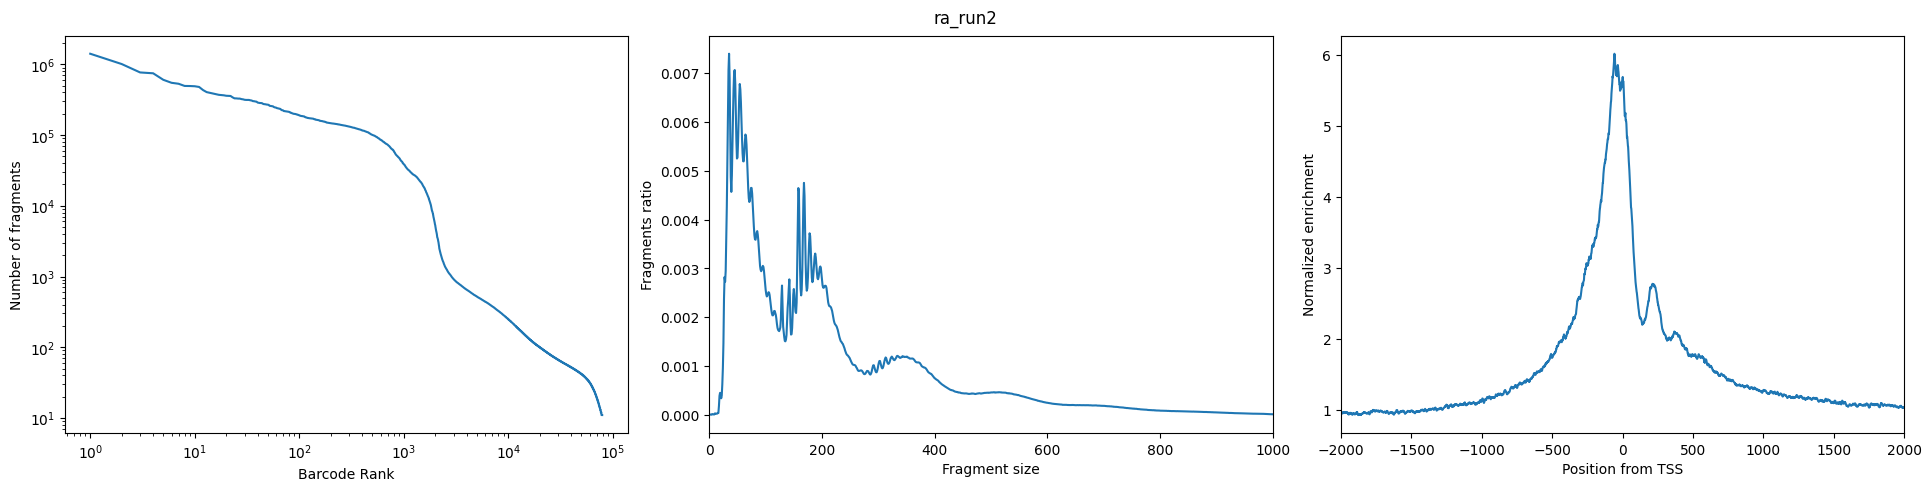

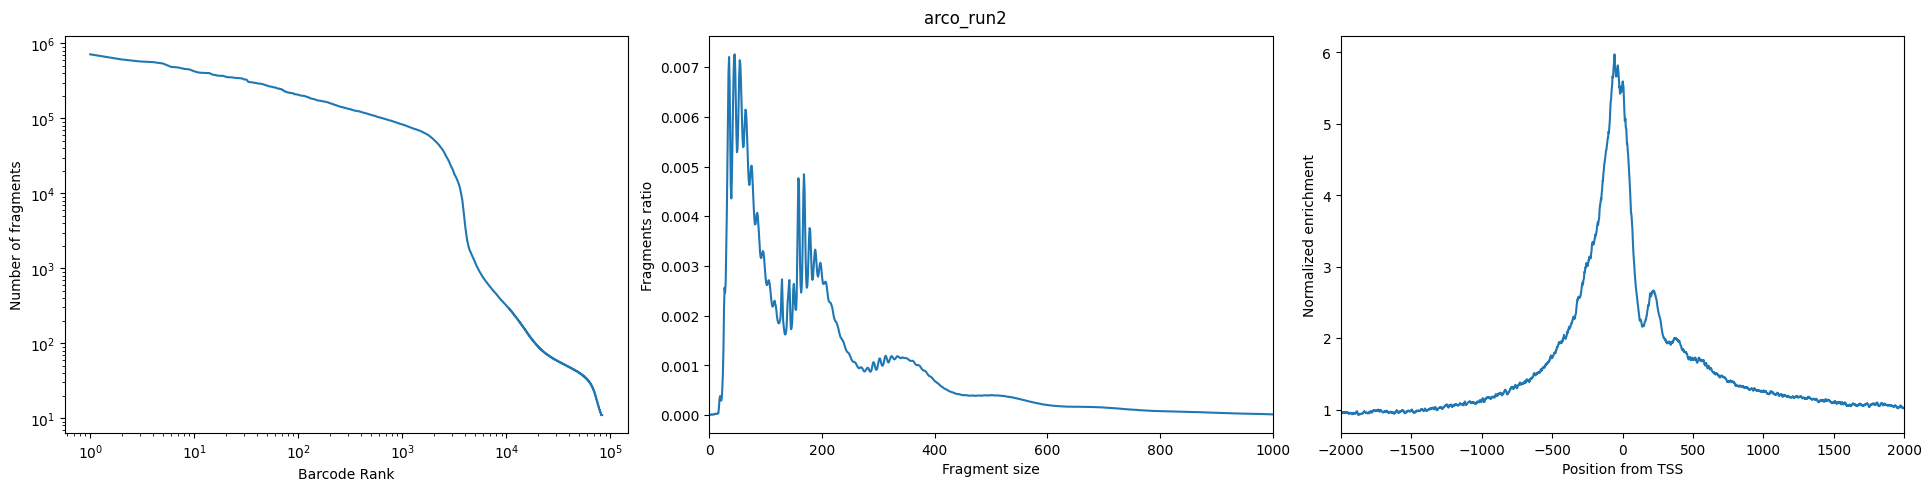

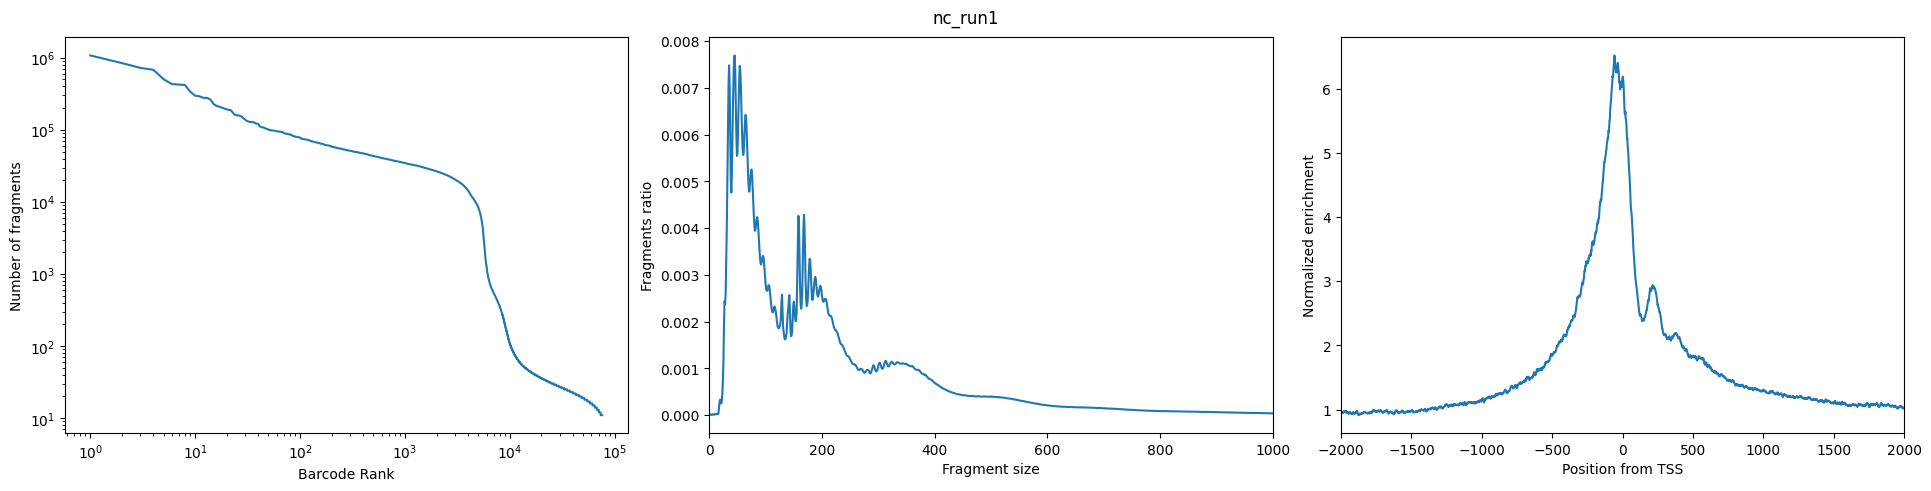

In [20]:
from pycisTopic.plotting.qc_plot import plot_sample_stats, plot_barcode_stats
import matplotlib.pyplot as plt

for sample_id in fragments_dict:
    fig = plot_sample_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = qc_dir
    )

In [21]:
from pycisTopic.qc import get_barcodes_passing_qc_for_sample
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
for sample_id in fragments_dict:
    (
        sample_id_to_barcodes_passing_filters[sample_id],
        sample_id_to_thresholds[sample_id]
    ) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir = qc_dir,
            unique_fragments_threshold = None, # use automatic thresholding
            #tss_enrichment_threshold = None, # use automatic thresholding
            tss_enrichment_threshold = 3,
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

ra_run2:
	Using automatic threshold for unique fragments: 1778.9835176560441
	Using user-defined threshold for TSS enrichment: 3
arco_run2:
	Using automatic threshold for unique fragments: 1905.9326979877592
	Using user-defined threshold for TSS enrichment: 3
nc_run1:
	Using automatic threshold for unique fragments: 1316.859114121273
	Using user-defined threshold for TSS enrichment: 3


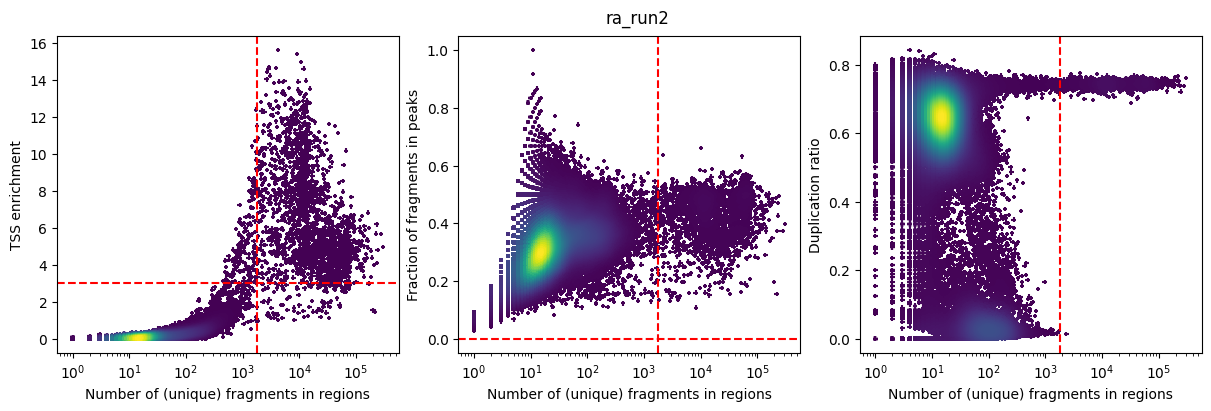

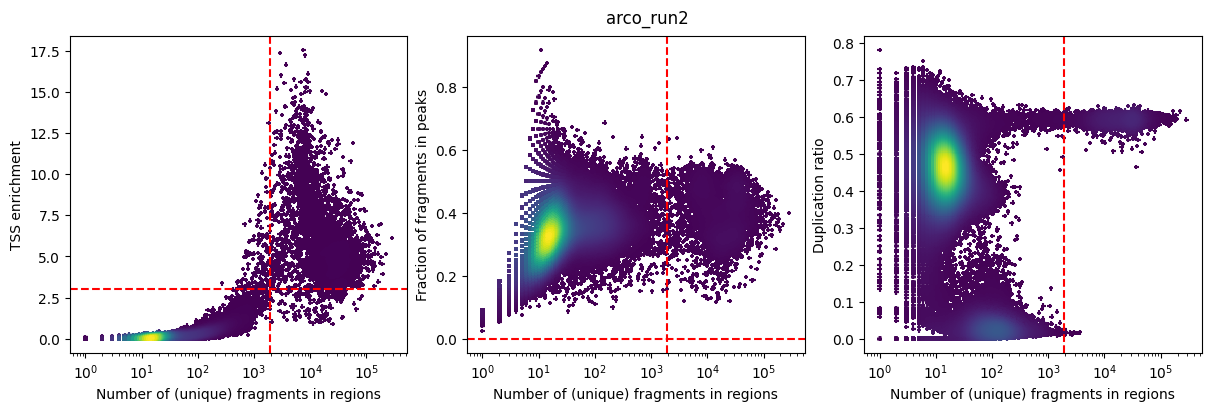

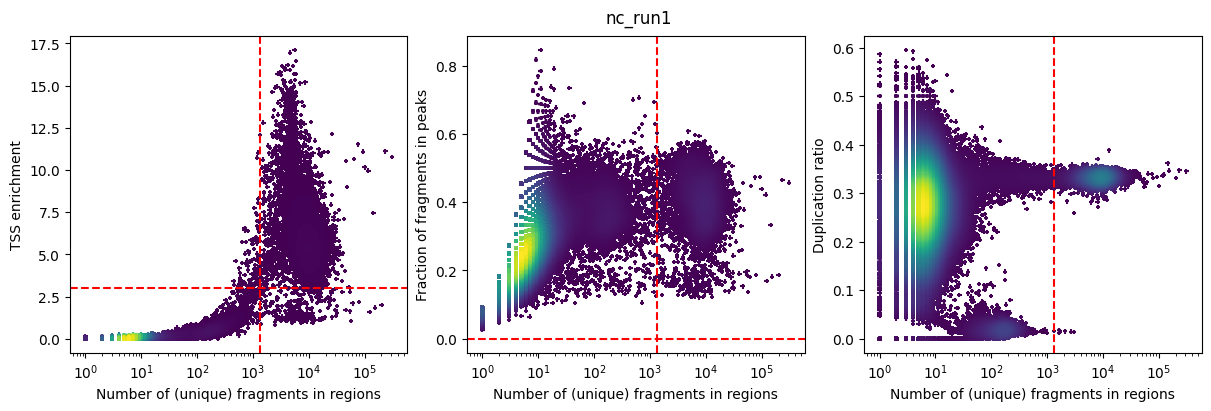

In [22]:
for sample_id in fragments_dict:
    fig = plot_barcode_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = qc_dir,
        bc_passing_filters = sample_id_to_barcodes_passing_filters[sample_id],
        detailed_title = False,
        **sample_id_to_thresholds[sample_id]
    )

In [23]:
cell_data

,cluster,position,assignment,sample_short,run,replicate,barcode
ACTCAGTAGGCCTTAG-1___nc_run1,Glut-Arco-1,arco,2,nc_run1,run1,rep1,ACTCAGTAGGCCTTAG-1
GAGTTTGGTTATGTGG-1___nc_run1,Glut-Arco-1,arco,2,nc_run1,run1,rep1,GAGTTTGGTTATGTGG-1
AAAGCCCGTTCCGGGA-1___ra_run2,Glut-RA,ra,0,ra_run2,run2,rep1,AAAGCCCGTTCCGGGA-1
AAAGGACGTGTGTGGT-1___ra_run2,Glut-RA,ra,0,ra_run2,run2,rep1,AAAGGACGTGTGTGGT-1
AAAGGAGCACTAGCGT-1___ra_run2,Glut-RA,ra,0,ra_run2,run2,rep1,AAAGGAGCACTAGCGT-1
...,...,...,...,...,...,...,...
TTTGACCGTTGGTTGA-1___arco_run2,Glut-Arco-1,arco,3,arco_run2,run2,rep1,TTTGACCGTTGGTTGA-1
TTTGCATTCCCGAACA-1___arco_run2,Glut-Arco-1,arco,1,arco_run2,run2,rep1,TTTGCATTCCCGAACA-1
TTTGGTGCATGTCGCG-1___arco_run2,Glut-Arco-1,arco,2,arco_run2,run2,rep1,TTTGGTGCATGTCGCG-1
TTTGTGAAGACTTACA-1___arco_run2,Glut-Arco-1,arco,0,arco_run2,run2,rep1,TTTGTGAAGACTTACA-1


### Create cisTopic object

In [24]:

cistopic_fname = os.path.join(work_dir, "cistopic_obj.pkl")

redo = False

if redo:
    path_to_regions = bed_fname
    #path_to_blacklist = "pycisTopic/blacklist/hg38-blacklist.v2.bed"
    pycistopic_qc_output_dir = qc_dir

    from pycisTopic.cistopic_class import create_cistopic_object_from_fragments
    import polars as pl

    cistopic_obj_list = []
    for sample_id in fragments_dict:
        sample_metrics = pl.read_parquet(
            os.path.join(pycistopic_qc_output_dir, f'{sample_id}.fragments_stats_per_cb.parquet')
        ).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample_id] ]
        cistopic_obj = create_cistopic_object_from_fragments(
            path_to_fragments = fragments_dict[sample_id],
            path_to_regions = path_to_regions,
            #path_to_blacklist = path_to_blacklist,
            metrics = sample_metrics,
            valid_bc = sample_id_to_barcodes_passing_filters[sample_id],
            n_cpu = 1,
            project = sample_id,
            split_pattern = '___'
        )
        cistopic_obj_list.append(cistopic_obj)

    from pycisTopic.cistopic_class import merge
    cistopic_obj = merge(cistopic_obj_list = cistopic_obj_list, project='ra-arco_glut')

    cistopic_obj.add_cell_data(cell_data)
    cistopic_obj
    
    pickle.dump(cistopic_obj, open(cistopic_fname, "wb"))
else:
    cistopic_obj = pickle.load(open(cistopic_fname, "rb"))


In [25]:
cistopic_obj.cell_data.cluster.value_counts()

Glut-Arco-1    487
Glut-RA        256
Name: cluster, dtype: int64

In [26]:
cells = cistopic_obj.cell_names
print(len(cells))
mask = cistopic_obj.cell_data.cluster.isnull().values
cells = np.array(cells)[~mask]
print(len(cells))
cells_list = cells.tolist()
print(cells_list[:5])
cistopic_obj_glut = cistopic_obj.subset(cells=cells_list, copy=True)
print(cistopic_obj)
print(cistopic_obj_glut)

10945
743
['AGAAACTAGCTAAGTC-1___ra_run2', 'GAACCAAAGCCACAAT-1___ra_run2', 'AAAGGAGCAGGCTAGA-1___ra_run2', 'CTAGTAGGTCACACCC-1___ra_run2', 'ATCCACCTCGATATTG-1___ra_run2']
CistopicObject from project ra-arco_glut with n_cells × n_regions = 10945 × 195092
CistopicObject from project ra-arco_glut with n_cells × n_regions = 743 × 195092


In [27]:
models_fname = os.path.join(work_dir, "models.pkl")

redo = False
if redo:

    os.environ['MALLET_MEMORY'] = '500G'
    from pycisTopic.lda_models import run_cgs_models_mallet

    # Configure path Mallet
    mallet_path="/home/brad/ssd/repos/Mallet-202108/bin/mallet"
    tmp_path = os.path.join(tmp_dir, "pycistopic_mallet")

    if not os.path.exists(tmp_path):
        os.makedirs(tmp_path)

    # Run models
    models=run_cgs_models_mallet(
        cistopic_obj_glut,
        n_topics=[2,4,6,8,10,15,20,30,40],
        n_cpu=40,
        n_iter=500,
        random_state=555,
        alpha=50,
        alpha_by_topic=True,
        eta=0.1,
        eta_by_topic=False,
        tmp_path=tmp_path,
        save_path=tmp_path,
        mallet_path=mallet_path,
    )

    pickle.dump(
        models,
        open(models_fname, "wb")
    )
else:
    models = pickle.load(open(models_fname, "rb"))

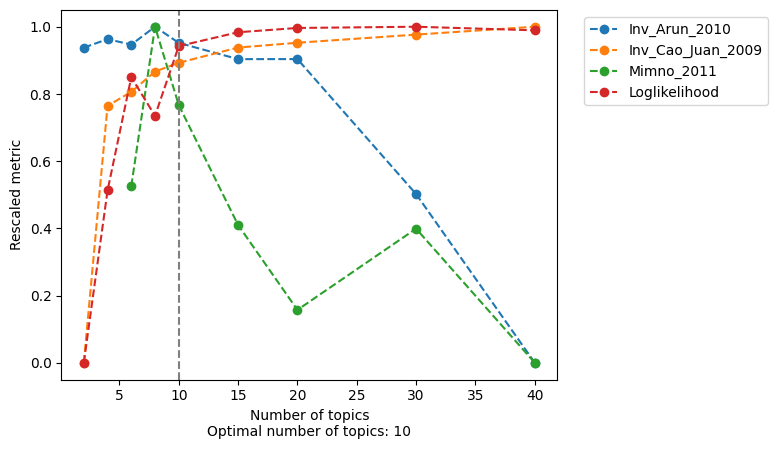

In [28]:
from pycisTopic.lda_models import evaluate_models
model = evaluate_models(
    models,
    select_model = 10,
    return_model = True
)

In [29]:
cistopic_obj_glut.cell_data.cluster

AGAAACTAGCTAAGTC-1___ra_run2      Glut-Arco-1
GAACCAAAGCCACAAT-1___ra_run2          Glut-RA
AAAGGAGCAGGCTAGA-1___ra_run2          Glut-RA
CTAGTAGGTCACACCC-1___ra_run2          Glut-RA
ATCCACCTCGATATTG-1___ra_run2          Glut-RA
                                     ...     
CTGTTTAGTACGATTG-1___arco_run2    Glut-Arco-1
TGATCAGGTTGGGTTA-1___arco_run2    Glut-Arco-1
CGTAGCGGTCACCTAT-1___arco_run2        Glut-RA
ACTCAGTAGGCCTTAG-1___nc_run1      Glut-Arco-1
GAGTTTGGTTATGTGG-1___nc_run1      Glut-Arco-1
Name: cluster, Length: 743, dtype: object

In [30]:
cistopic_obj_glut.add_LDA_model(model)

pickle.dump(
    cistopic_obj_glut,
    open(os.path.join(work_dir, "cistopic_obj_glut.pkl"), "wb")
)

## Batch correct

In [31]:
import harmonypy as hm
import copy
cell_data_cur = cistopic_obj_glut.cell_data.copy()
cell_data_cur['run'] = cell_data_cur.sample_short.str.split('_').str[1]

df = cistopic_obj_glut.selected_model.cell_topic
df_scaled = df.apply(lambda x: (x - x.mean()) / x.std(), axis=1).T
df_scaled

ho = hm.run_harmony(df_scaled, cell_data_cur, 'run')
res = pd.DataFrame(ho.Z_corr)
res.index = df_scaled.columns
res.columns = df_scaled.index

cistopic_obj_glut_hm = copy.deepcopy(cistopic_obj_glut)
cistopic_obj_glut_hm.selected_model.cell_topic = res

2026-02-02 15:35:51,720 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2026-02-02 15:35:51,943 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2026-02-02 15:35:51,945 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2026-02-02 15:35:51,987 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2026-02-02 15:35:52,029 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2026-02-02 15:35:52,073 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2026-02-02 15:35:52,115 - harmonypy - INFO - Iteration 5 of 10
INFO:harmonypy:Iteration 5 of 10
2026-02-02 15:35:52,139 - harmonypy - INFO - Iteration 6 of 10
INFO:harmonypy:Iteration 6 of 10
2026-02-02 15:35:52,153 - harmonypy - INFO - Iteration 7 of 10
INFO:harmonypy:Iteration 7 of 10
2026-02-02 15:35:52,166 - 

## Visualization

In [32]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [33]:
find_clusters(
    cistopic_obj_glut,
    target  = 'cell',
    k = 10,
    res = [0.6, 1.2, 3],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '-'
)

INFO:cisTopic:Finding neighbours


In [34]:
import umap
umap.__version__

'0.5.5'

In [35]:
run_umap(
    cistopic_obj_glut,
    target  = 'cell', scale=True)
run_tsne(
    cistopic_obj_glut,
    target  = 'cell', scale=True)

INFO:cisTopic:Running UMAP
/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
INFO:cisTopic:Running TSNE


In [36]:
run_umap(
    cistopic_obj_glut_hm,
    target  = 'cell', scale=True)
run_tsne(
    cistopic_obj_glut_hm,
    target  = 'cell', scale=True)

INFO:cisTopic:Running UMAP
/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
INFO:cisTopic:Running TSNE


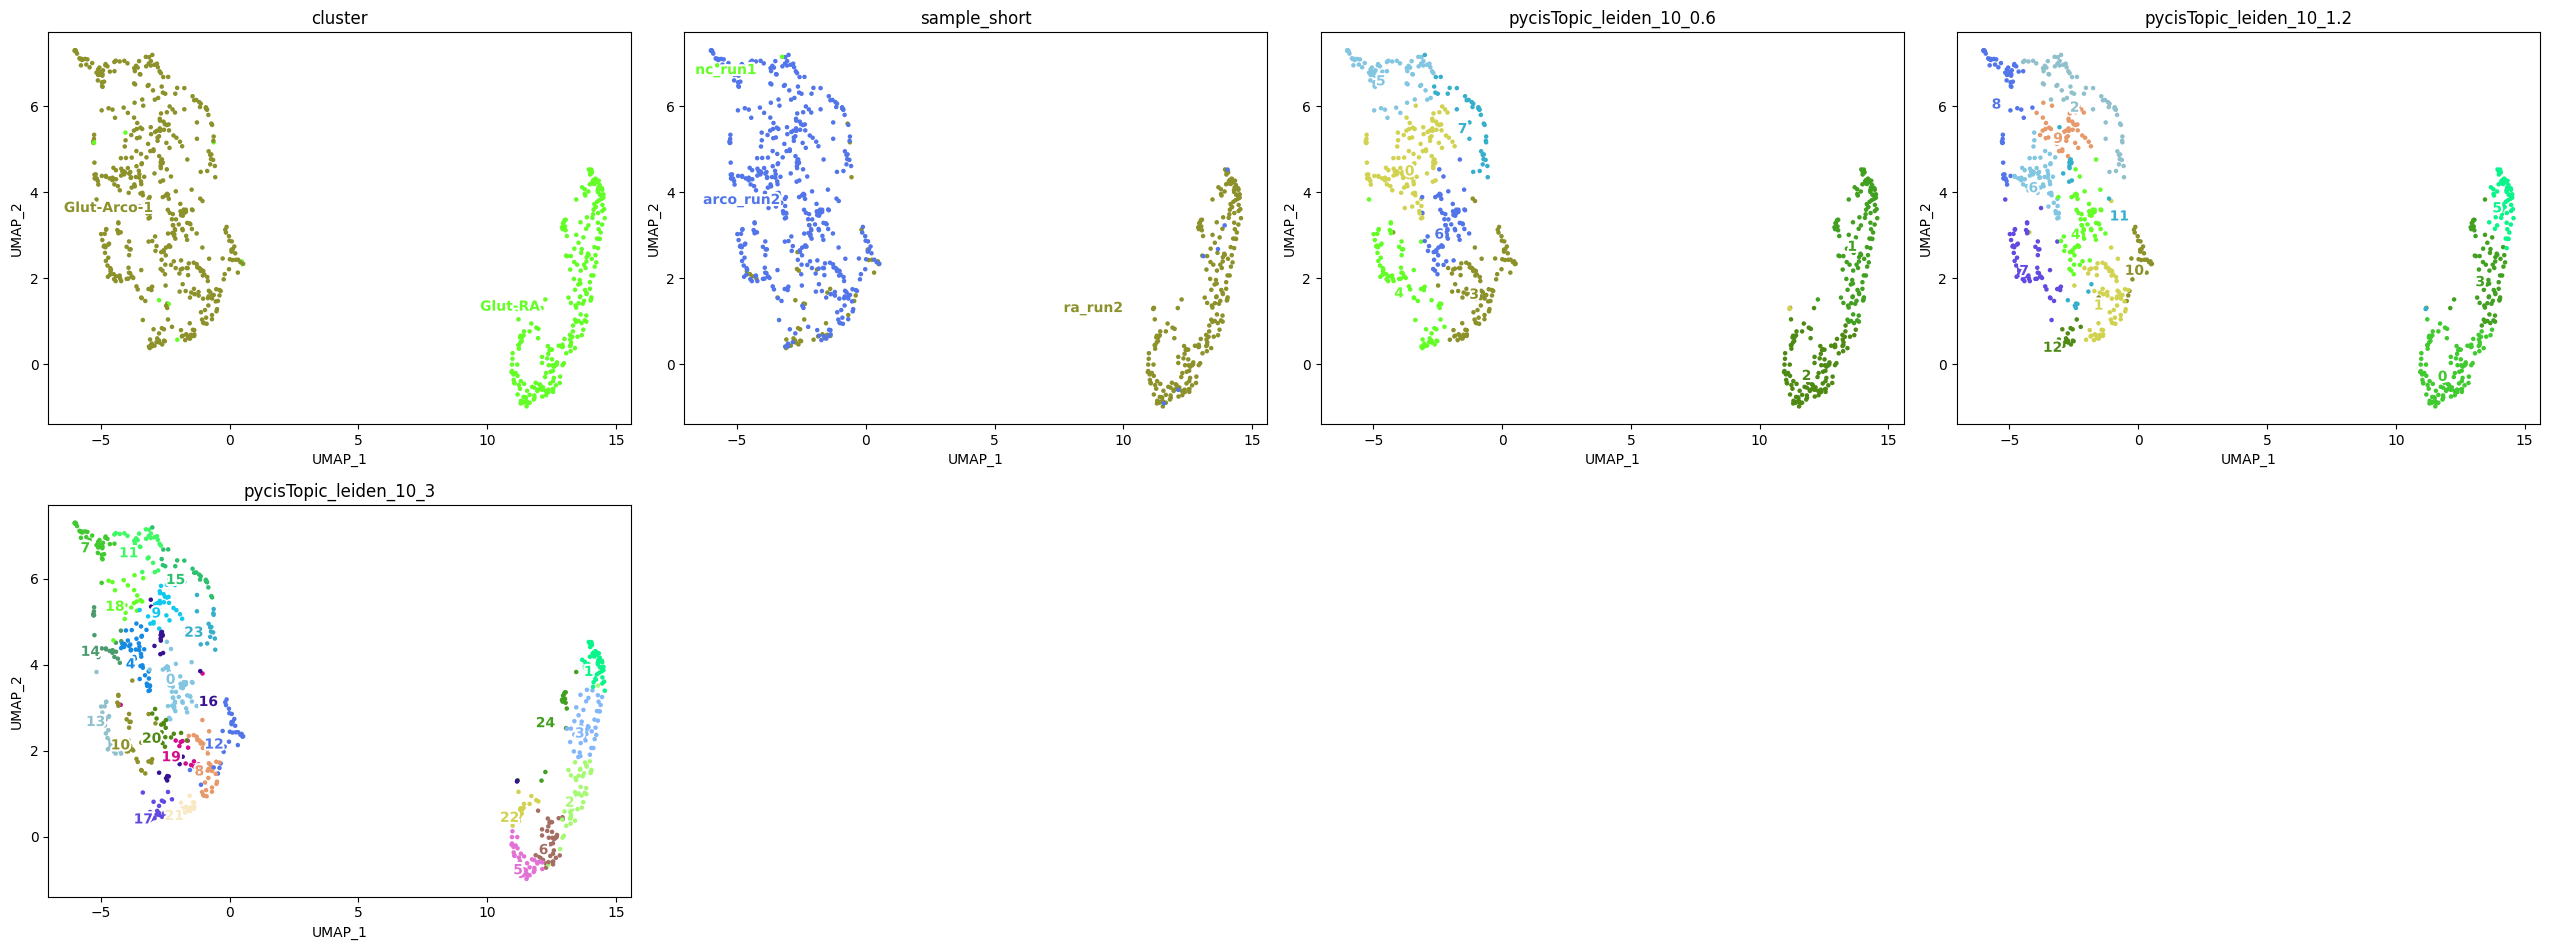

In [37]:
plot_metadata(
    cistopic_obj_glut,
    reduction_name='UMAP',
    variables=['cluster', 'sample_short', 'pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

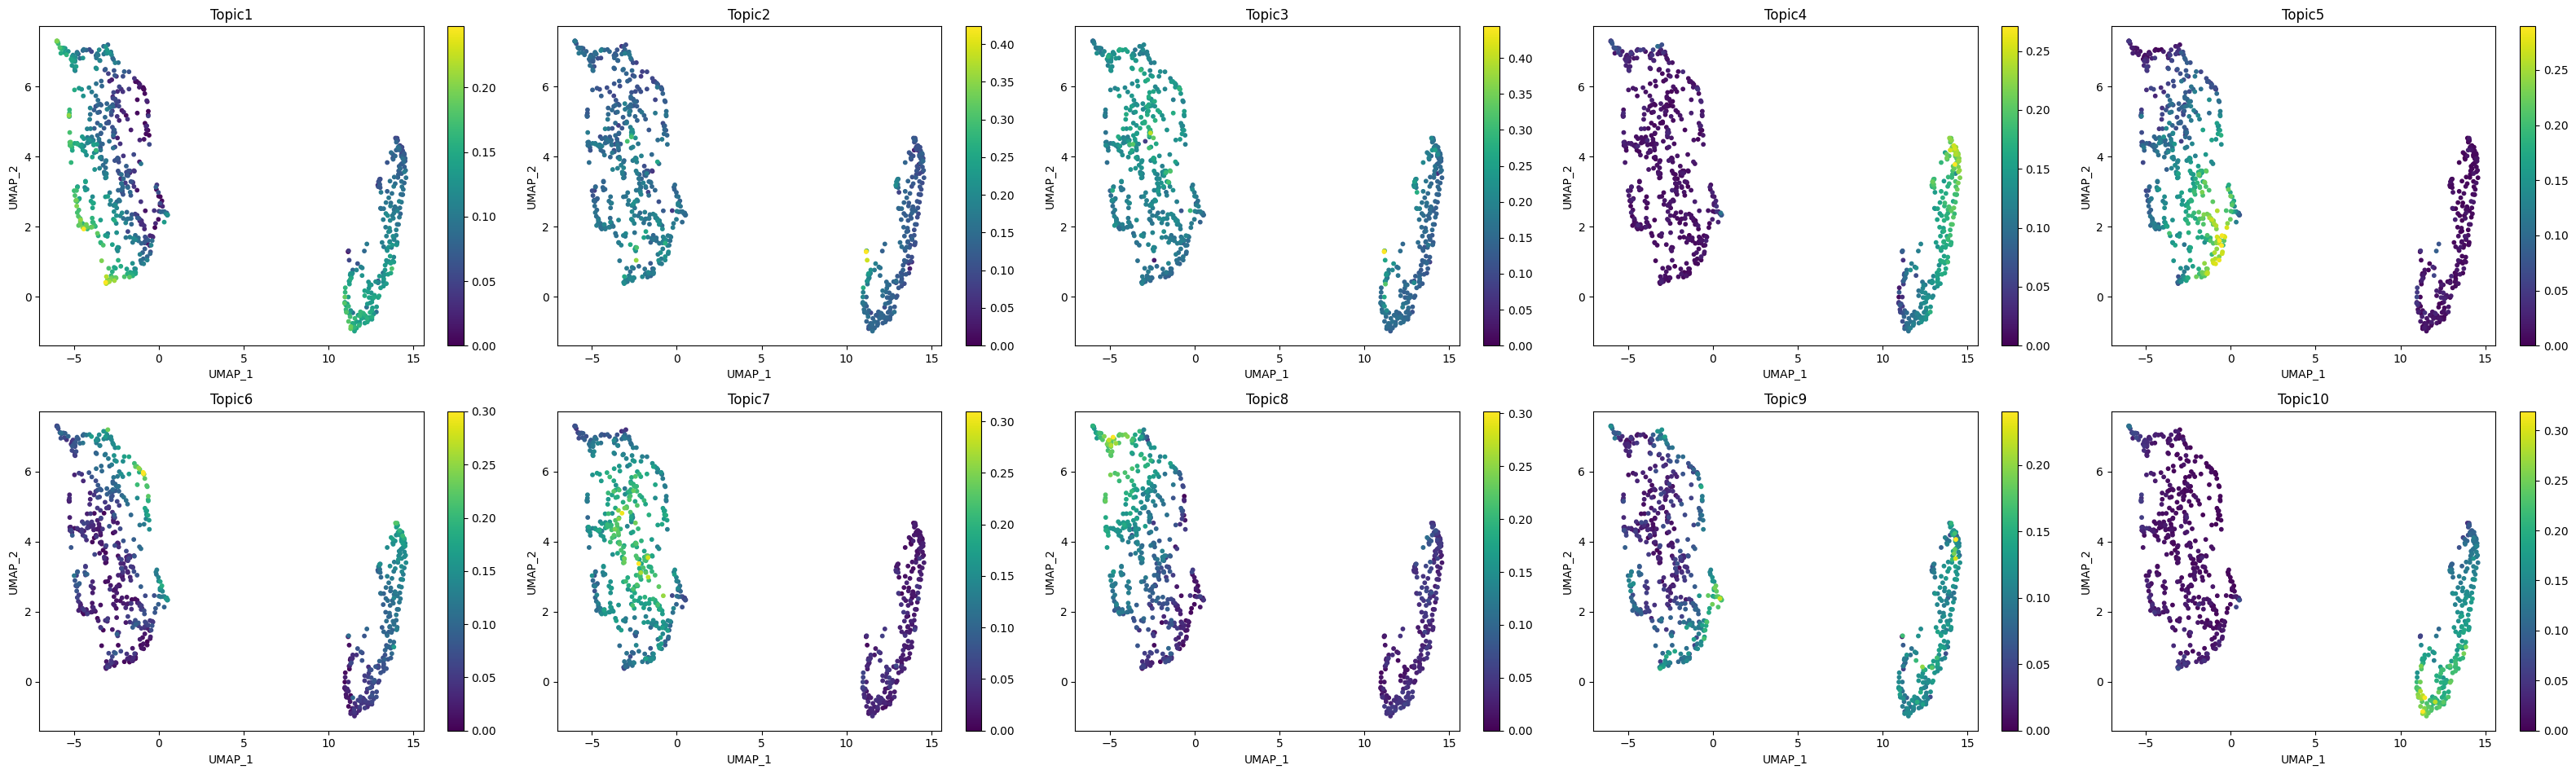

In [38]:
plot_topic(
    cistopic_obj_glut,
    reduction_name = 'UMAP',
    target = 'cell',
    num_columns=5
)

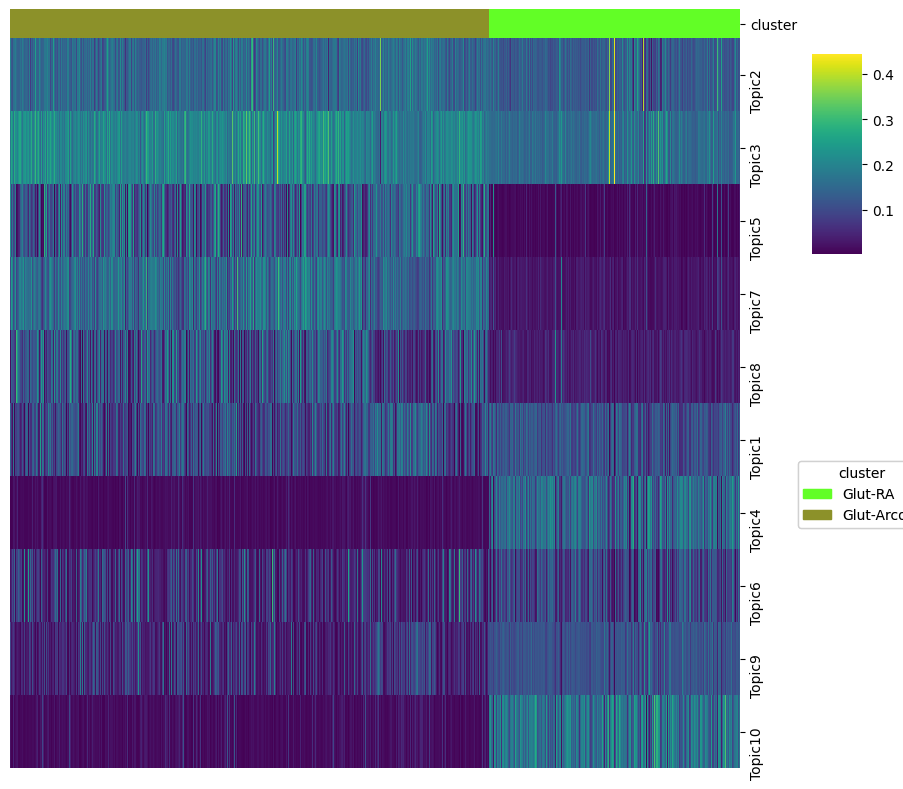

In [39]:
cistopic_obj_glut.cell_data['cluster'] = cistopic_obj_glut.cell_data['cluster'].astype(str)
cell_topic_heatmap(
    cistopic_obj_glut,
    variables = ["cluster"],
    scale = False,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10)
)

### Binarize

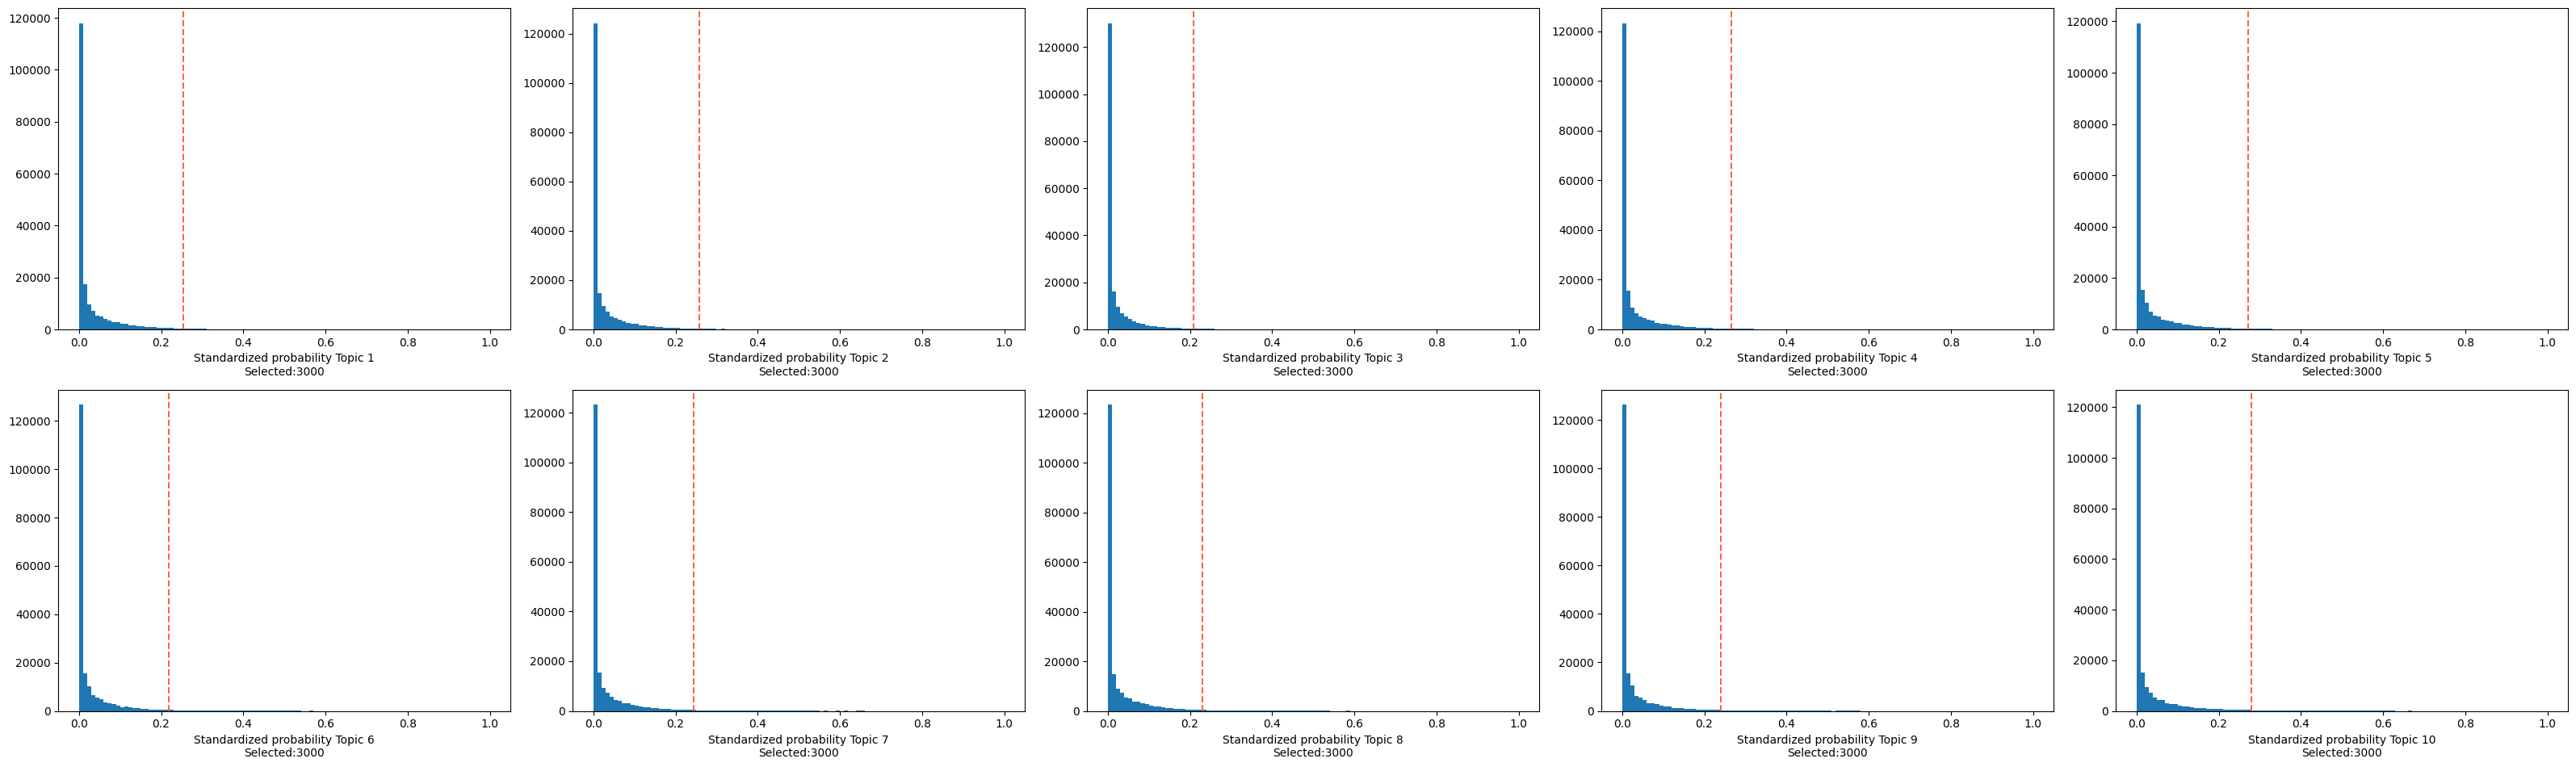

In [40]:
from pycisTopic.topic_binarization import binarize_topics
region_bin_topics_top_3k = binarize_topics(
    cistopic_obj_glut, method='ntop', ntop = 3_000,
    plot=True, num_columns=5
)

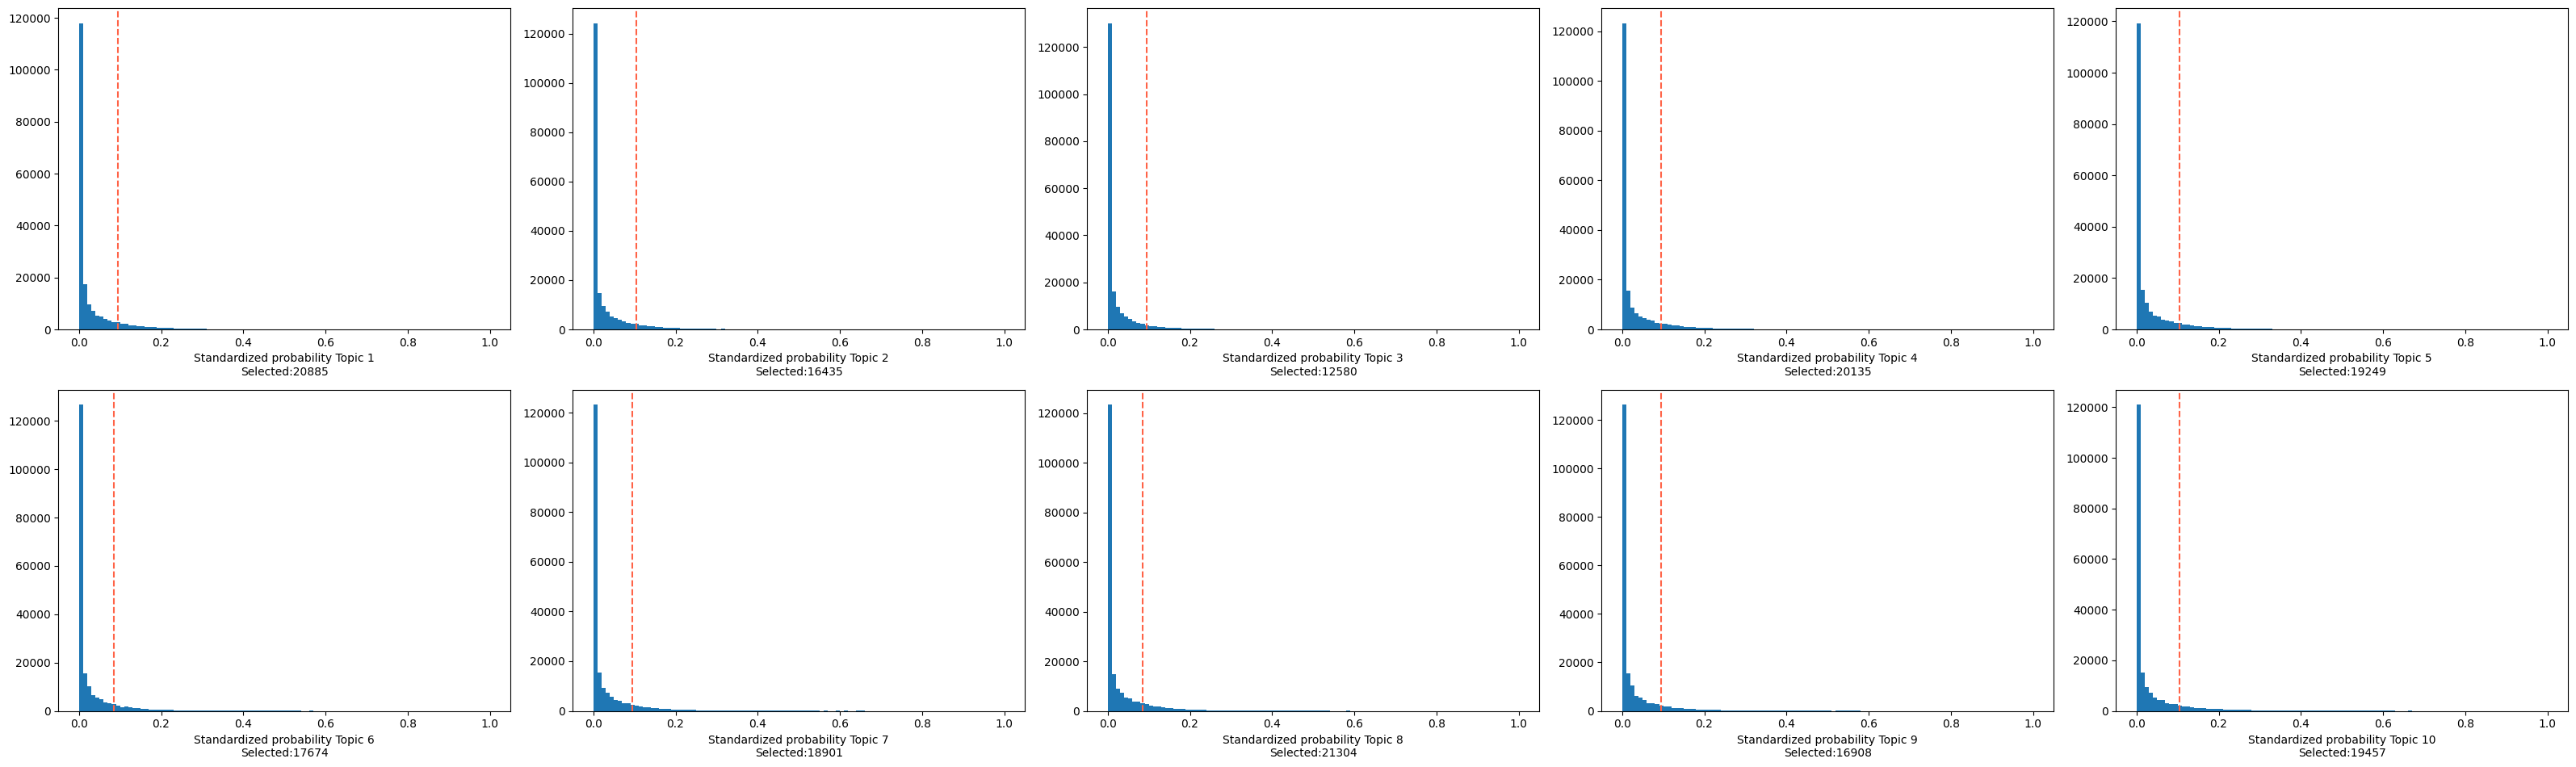

In [41]:
region_bin_topics_otsu = binarize_topics(
    cistopic_obj_glut, method='otsu',
    plot=True, num_columns=5
)

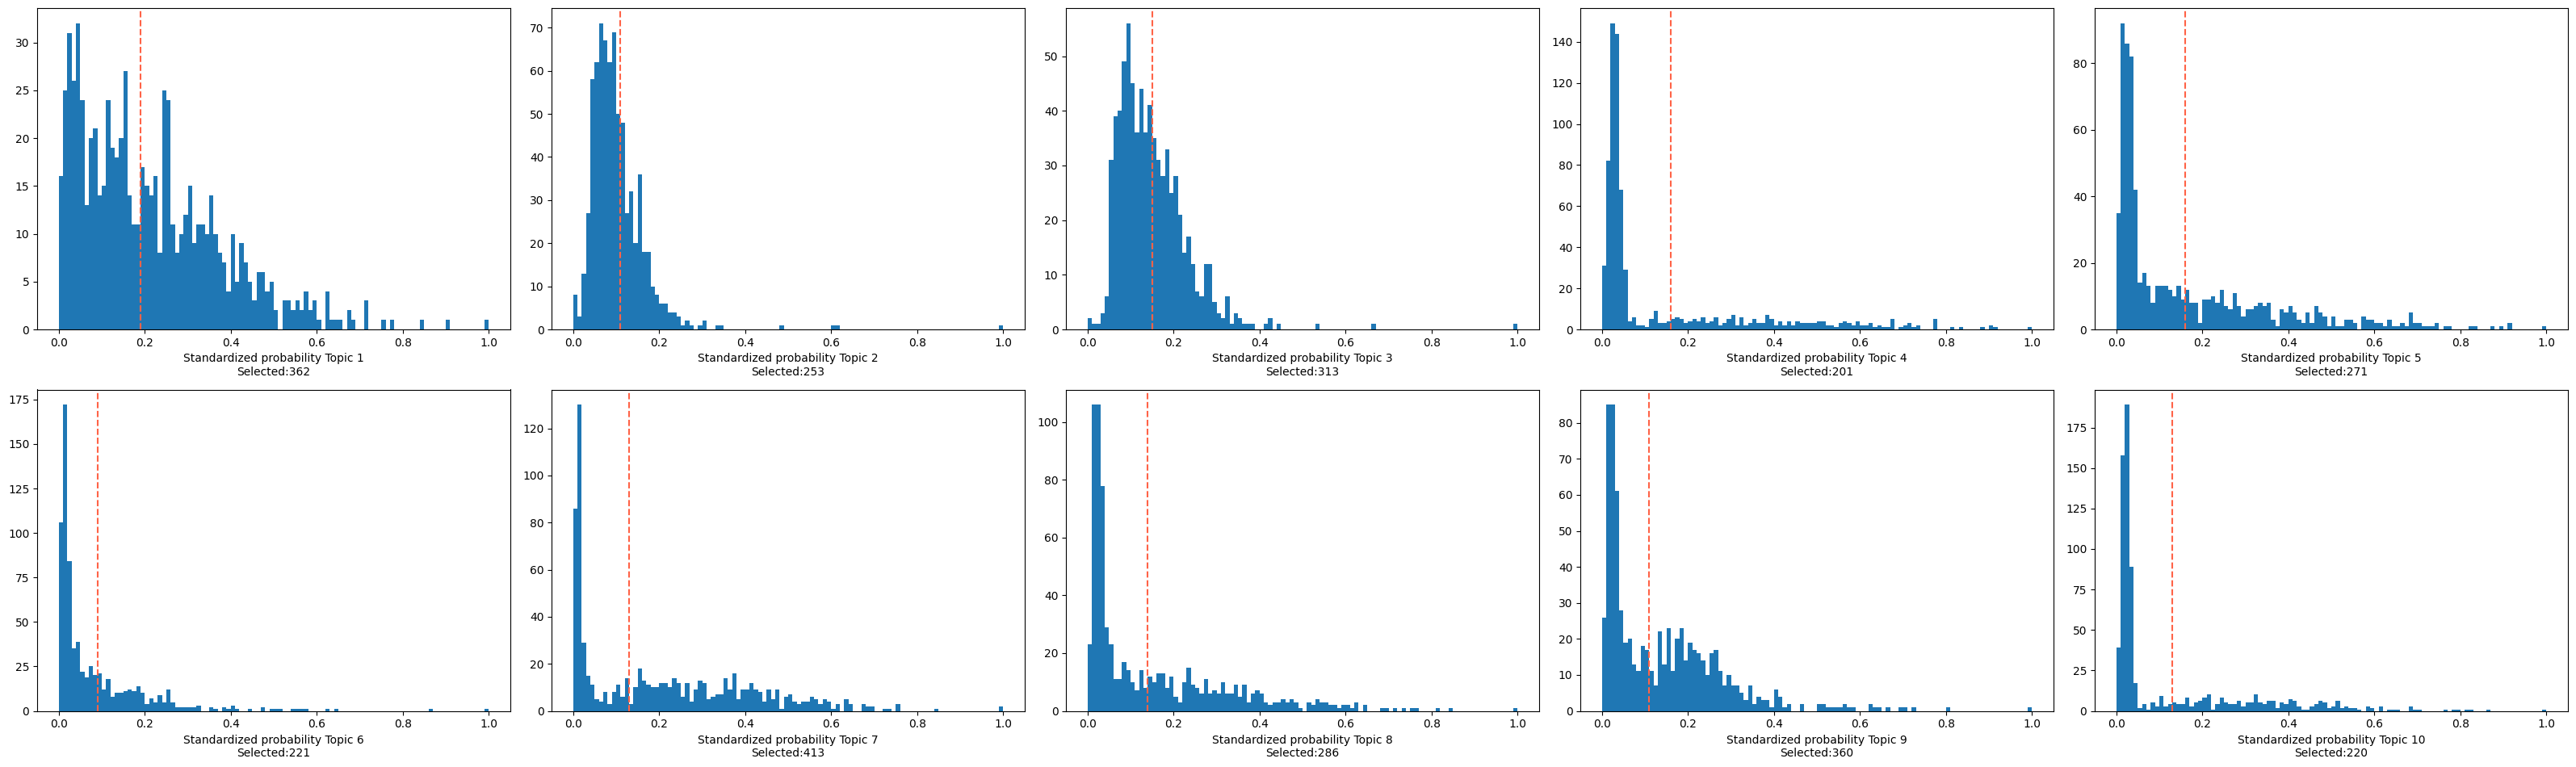

In [42]:
binarized_cell_topic = binarize_topics(
    cistopic_obj_glut,
    target='cell',
    method='li',
    plot=True,
    smooth_topics=True,
    num_columns=5, nbins=100)

In [43]:
from pycisTopic.topic_qc import compute_topic_metrics, plot_topic_qc, topic_annotation
import matplotlib.pyplot as plt
from pycisTopic.utils import fig2img

In [44]:
topic_qc_metrics = compute_topic_metrics(cistopic_obj_glut)

In [45]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Log10_Assignments', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['AssignmentsVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Log10_Assignments', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSRegions_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Regions_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSMarginal_dist']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSGini_index']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', var_color='Gini_index', plot=False, return_fig=True)

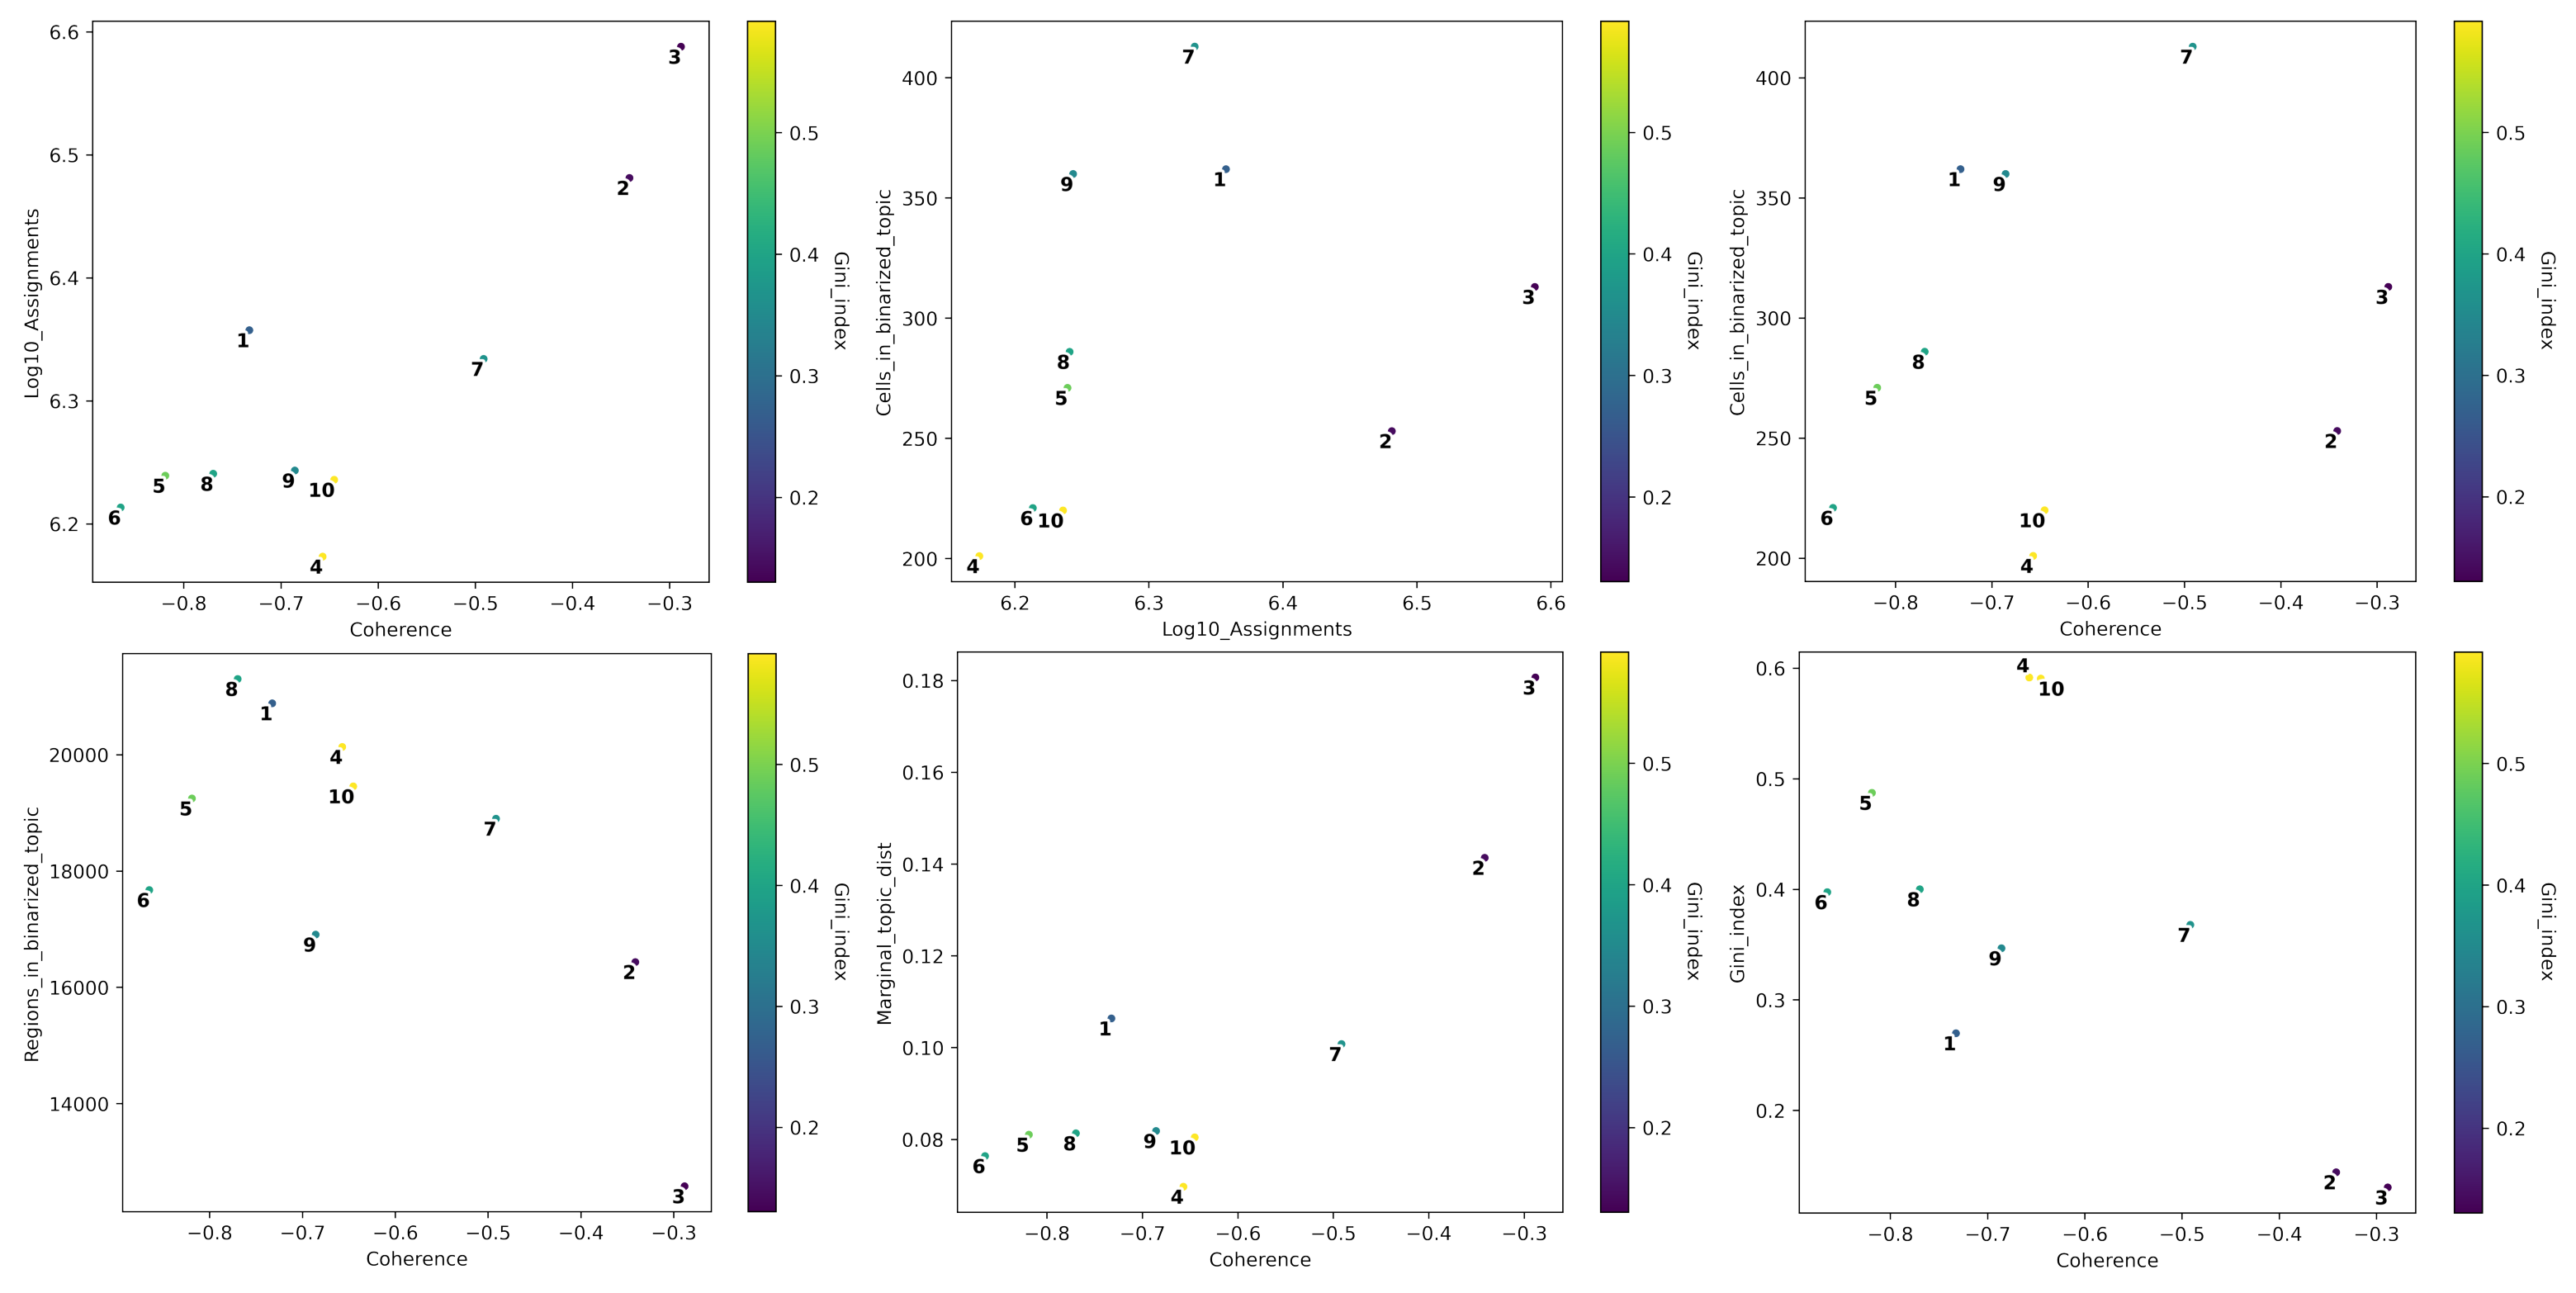

In [46]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
plt.show()

In [47]:
topic_annot = topic_annotation(
    cistopic_obj_glut,
    annot_var='cluster',
    binarized_cell_topic=binarized_cell_topic,
    general_topic_thr = 0.2
)

topic_annot

/home/brad/micromamba/envs/scenicplus/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: divide by zero encountered in scalar divide
  zstat = value / std


,cluster,Ratio_cells_in_topic,Ratio_group_in_population,is_general
Topic1,,0.487214,0.0,True
Topic2,Glut-Arco-1,0.340511,0.655451,False
Topic3,Glut-Arco-1,0.421265,0.655451,False
Topic4,Glut-RA,0.270525,0.344549,False
Topic5,Glut-Arco-1,0.364738,0.655451,False
Topic6,Glut-RA,0.297443,0.344549,False
Topic7,Glut-Arco-1,0.555855,0.655451,False
Topic8,Glut-Arco-1,0.384926,0.655451,False
Topic9,Glut-RA,0.484522,0.344549,False
Topic10,Glut-RA,0.296097,0.344549,False


### DARs

In [72]:
cistopic_obj_glut.

In [48]:
from pycisTopic.diff_features import (
    impute_accessibility,
    normalize_scores,
    find_highly_variable_features,
    find_diff_features
)
import numpy as np

In [49]:
imputed_acc_obj = impute_accessibility(
    cistopic_obj_glut,
    selected_cells=None,
    selected_regions=None,
    scale_factor=10**6
)

INFO:cisTopic:Imputing region accessibility
INFO:cisTopic:Impute region accessibility for regions 0-20000
INFO:cisTopic:Impute region accessibility for regions 20000-40000
INFO:cisTopic:Impute region accessibility for regions 40000-60000
INFO:cisTopic:Impute region accessibility for regions 60000-80000
INFO:cisTopic:Impute region accessibility for regions 80000-100000
INFO:cisTopic:Impute region accessibility for regions 100000-120000
INFO:cisTopic:Impute region accessibility for regions 120000-140000
INFO:cisTopic:Impute region accessibility for regions 140000-160000
INFO:cisTopic:Impute region accessibility for regions 160000-180000
INFO:cisTopic:Impute region accessibility for regions 180000-200000
INFO:cisTopic:Done!


In [50]:
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

INFO:cisTopic:Normalizing imputed data
INFO:cisTopic:Done!


INFO:cisTopic:Calculating mean
INFO:cisTopic:Calculating variance


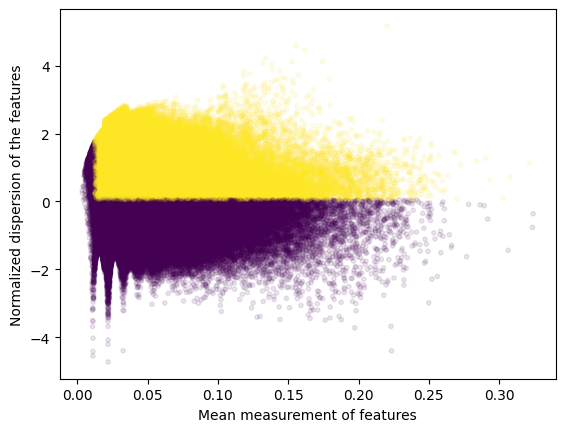

INFO:cisTopic:Done!


In [51]:
variable_regions = find_highly_variable_features(
    normalized_imputed_acc_obj,
    min_disp = 0.05,
    min_mean = 0.0125,
    max_mean = 3,
    max_disp = np.inf,
    n_bins=20,
    n_top_features=None,
    plot=True
)

In [52]:
len(variable_regions)

87398

#### All

In [53]:
ray.shutdown()

In [ ]:
markers_dict_all = find_diff_features(
    cistopic_obj_glut,
    imputed_acc_obj,
    variable='cluster',
    var_features=variable_regions,
    contrasts=None,
    adjpval_thr=0.1,
    log2fc_thr=np.log2(1.5),
    n_cpu=40,
    _temp_dir=tmp_dir,
    split_pattern = '-'
)

2026-02-02 16:12:14,905	INFO worker.py:1724 -- Started a local Ray instance.
INFO:cisTopic:Subsetting data for Glut-Arco-1 (487 of 743)
INFO:cisTopic:Computing p-value for Glut-Arco-1
INFO:cisTopic:Computing log2FC for Glut-Arco-1
INFO:cisTopic:Glut-Arco-1 done!
INFO:cisTopic:Subsetting data for Glut-RA (256 of 743)
INFO:cisTopic:Computing p-value for Glut-RA
INFO:cisTopic:Computing log2FC for Glut-RA
INFO:cisTopic:Glut-RA done!


In [64]:
from pycisTopic.clust_vis import plot_imputed_features

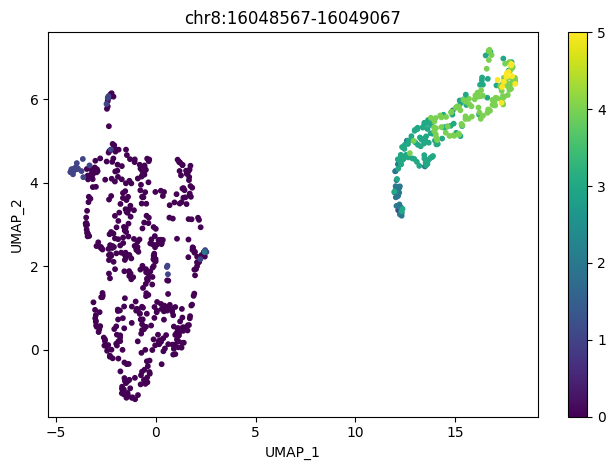

In [65]:
plot_imputed_features(
    cistopic_obj_glut_hm,
    reduction_name='UMAP',
    imputed_data=imputed_acc_obj,
    features=[markers_dict_all[x].index.tolist()[0] for x in ["Glut-RA"]],
    scale=False,
    num_columns=4
)

In [66]:
print("Number of DARs found:")
print("---------------------")
for x in markers_dict_all:
    print(f"  {x}: {len(markers_dict_all[x])}")


Number of DARs found:
---------------------
  Glut-Arco-1: 39847
  Glut-RA: 45995


### Save regions

In [67]:
work_dir

'/hdd/jupyter/brad/scenicplus/motor-pathway_multiome/motor-pathway_multiome_seurat_cellbender.0.05_preprocess_cr/glut-ra_glut-arco-1_run2_seurat-snrna-clustering/pycisTopic/'

In [68]:
os.makedirs(os.path.join(work_dir, "region_sets"), exist_ok = True)
os.makedirs(os.path.join(work_dir, "region_sets", "Topics_otsu"), exist_ok = True)
os.makedirs(os.path.join(work_dir, "region_sets", "Topics_top_3k"), exist_ok = True)
os.makedirs(os.path.join(work_dir, "region_sets", "DARs_all"), exist_ok = True)


In [69]:
from pycisTopic.utils import region_names_to_coordinates

In [70]:
for topic in region_bin_topics_otsu:
    region_names_to_coordinates(
        region_bin_topics_otsu[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(work_dir, "region_sets", "Topics_otsu", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )
    
for topic in region_bin_topics_top_3k:
    region_names_to_coordinates(
        region_bin_topics_top_3k[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(work_dir, "region_sets", "Topics_top_3k", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )
    
for cell_type in markers_dict_all:
    region_names_to_coordinates(
        markers_dict_all[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(work_dir, "region_sets", "DARs_all", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

"""
for cell_type in markers_dict_pairs:
    region_names_to_coordinates(
        markers_dict_pairs[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(work_dir, "region_sets", "DARs_song-pairs", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

"""

'\nfor cell_type in markers_dict_pairs:\n    region_names_to_coordinates(\n        markers_dict_pairs[cell_type].index\n    ).sort_values(\n        ["Chromosome", "Start", "End"]\n    ).to_csv(\n        os.path.join(work_dir, "region_sets", "DARs_song-pairs", f"{cell_type}.bed"),\n        sep = "\t",\n        header = False, index = False\n    )\n\n'

In [71]:
# Pickle
regions_dir = os.path.join(work_dir, "region_sets")
pickle.dump(region_bin_topics_otsu, open(os.path.join(regions_dir, "region_bin_topics_otsu.pkl"), 'wb'))
pickle.dump(region_bin_topics_top_3k, open(os.path.join(regions_dir, "region_bin_topics_top3k.pkl"), 'wb'))
pickle.dump(markers_dict_all, open(os.path.join(regions_dir, "markers_dict_all.pkl"), 'wb'))
